In [1]:

import pandas as pd

In [2]:
path = "data.csv"

df = pd.read_csv(path)

print(df.head())

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

In [3]:
# full data set contains 4600 rows
df.isnull().sum().sum()

np.int64(0)

In [4]:
# So there are no null values in our dataset.
df['country'].value_counts()

country
USA    4600
Name: count, dtype: int64

In [5]:
# All data points are from US as expected. I will drop the column because of this
df.drop(columns=['country'], inplace=True)

# Rest of the columns are reasonably named, so I will not alther them.

In [6]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
dtypes: float64(4), int64(9), object(4)
memory usage: 611

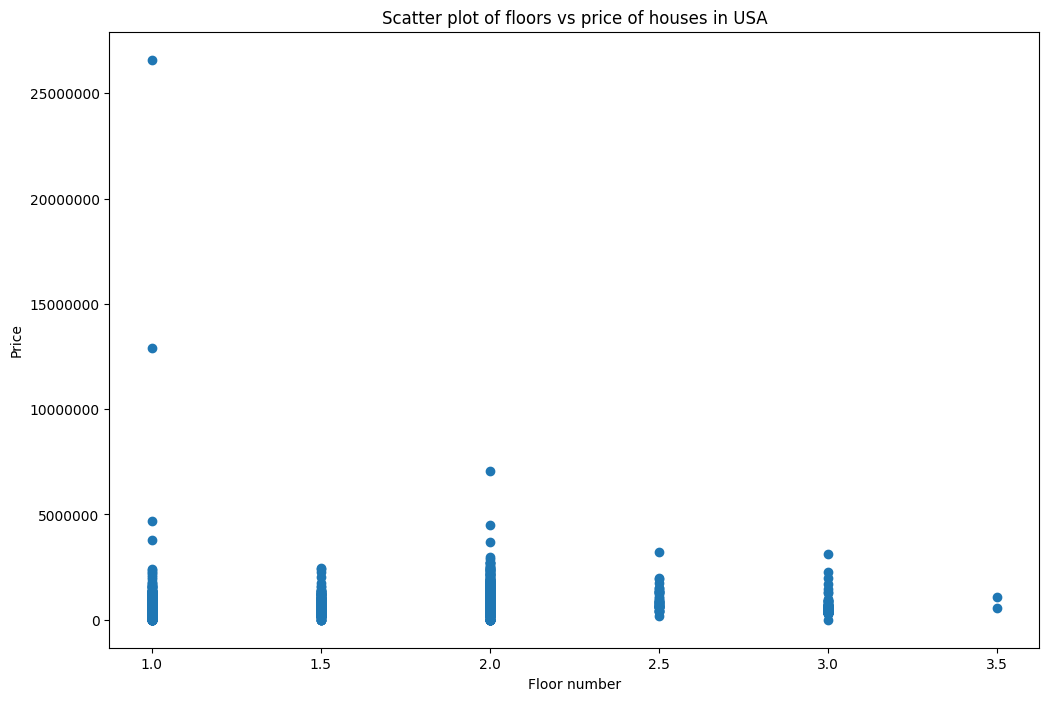

In [26]:
import matplotlib.pyplot as plt
import matplotlib as mpl

x = df['floors']
y = df['price']
# Scatter plot of floors vs price

plt.figure(figsize=(12,8))
plt.ticklabel_format(style='plain', axis='y')
plt.scatter(x=x, y=y)
plt.title('Scatter plot of floors vs price of houses in USA')
plt.xlabel('Floor number')
plt.ylabel('Price')
plt.savefig("Scatterplot_floors_vs_price.png")
plt.show()

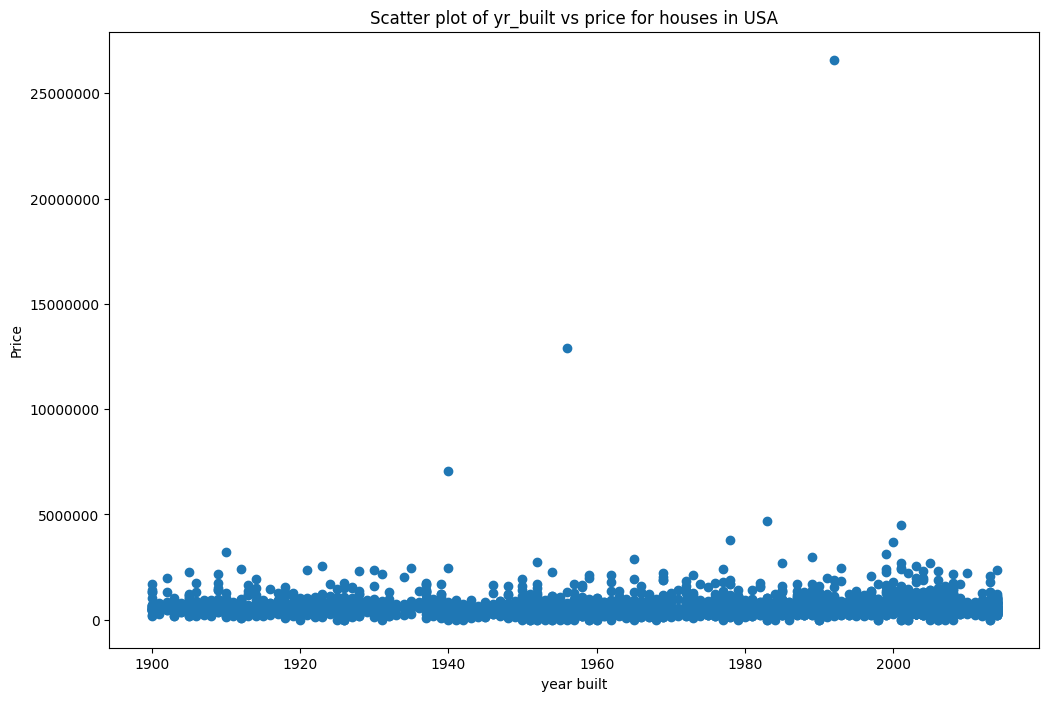

In [27]:
# Scatter plot of floors vs price
x = df['yr_built']
y = df['price']


plt.figure(figsize=(12,8))
plt.ticklabel_format(style='plain', axis='y') # Changed ticklabel to plain numbers, I find it more comfortable for checking different values.
plt.scatter(x=x, y=y)
plt.title('Scatter plot of yr_built vs price for houses in USA')
plt.xlabel('year built')
plt.ylabel('Price')
plt.savefig('scatterplot_yr_built_vs_price.png')
plt.show()


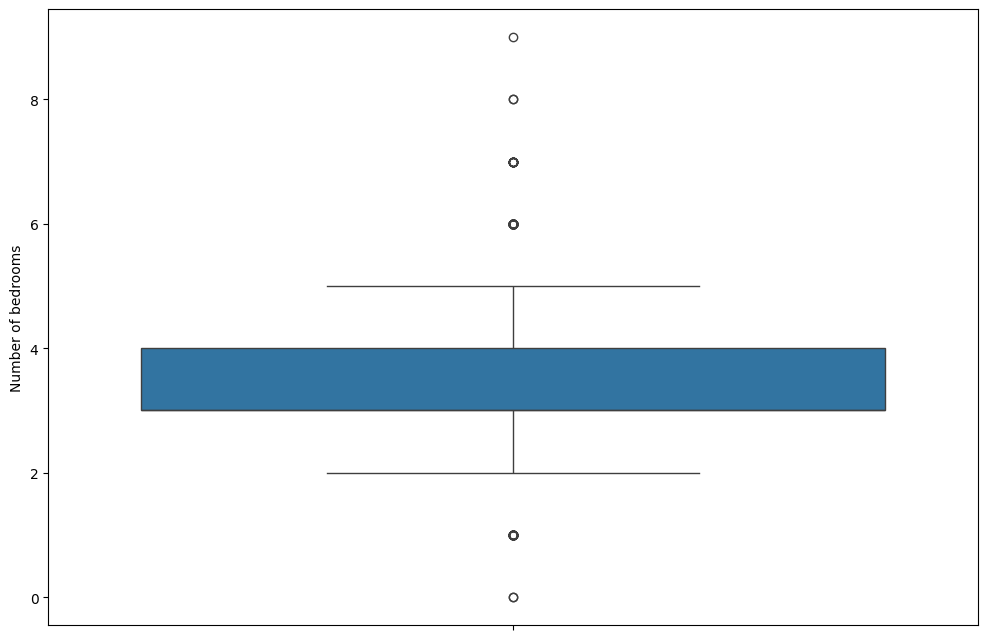

In [25]:
import seaborn as sns
# Create box plot of a feature to find an outlier
y = df['price'] # Find houses with an outlier price 

Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

plt.figure(figsize=(12,8))
sns.boxplot(y="bedrooms",
            data=df)
plt.ylabel('Number of bedrooms')
plt.savefig('boxplot_n_of_bedrooms.png')
plt.show()




In [13]:
# We can see that this data base does not have many studio apartments and most homes have between 2 and 5 bedrooms. There are outliers with as many as 9 rooms.
# There is also an outlier with 0 bedrooms. This could be an error in data I didn't notice before. It could also represent a studio apartment, where living room and bedroom are combined,
# resulting in this statistical anomaly.

df.info()

#Create heatmap to show correlation between features.
# sns.heatmap(df, annot=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
dtypes: float64(4), int64(9), object(4)
memory usage: 611

In [ ]:
#For line plot, let's look at price changes over time

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')


KeyError: 'date'

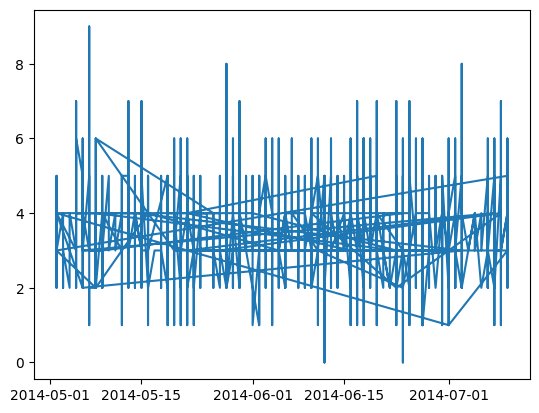

In [ ]:

plt.plot(df.index, df['bedrooms'])

plt.show()

#As we can see there was a problem here. I had no time to study why this happened, but my first guess would be I converted the dates incorrectly.
#For example European dd/mm/yyyy and American mm/dd/yyyy